# Load Parsed Table

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Search the current working directory and all its parents for the project root.
CWD = Path.cwd().resolve()
ROOT = next(
    (path for path in (CWD, *CWD.parents) if (path / "requirements.txt").is_file()),
    None,
)

if ROOT is None:
    raise RuntimeError(f"Cannot find the project root from working directory: {CWD}")

print(f"Working directory: {CWD}")
print(f"Project root: {ROOT}")

reads = pd.read_parquet(ROOT / "data/processed/data1_reads.parquet")

SITE_KEYS = ["transcript_id", "transcript_position"]

display(reads.head())
print(f"Read rows: {len(reads):,}")

Working directory: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/notebooks/indiv_data_eda
Project root: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies


,transcript_id,transcript_position,sequence,central_5mer,n_reads,read_idx,minus1_dwell,minus1_signal_sd,minus1_signal_mean,central_dwell,central_signal_sd,central_signal_mean,plus1_dwell,plus1_signal_sd,plus1_signal_mean,gene_id,label
0,ENST00000000233,244,AAGACCA,AGACC,165,0,0.00465,2.16,127.0,0.00640,3.90,127.0,0.00797,8.75,83.7,NaN,0.0
1,ENST00000000233,244,AAGACCA,AGACC,165,1,0.02690,4.43,106.0,0.01860,10.00,123.0,0.00863,6.20,80.0,NaN,0.0
2,ENST00000000233,244,AAGACCA,AGACC,165,2,0.00432,3.10,108.0,0.01200,8.26,125.0,0.01590,2.89,78.7,NaN,0.0
3,ENST00000000233,244,AAGACCA,AGACC,165,3,0.00996,4.52,123.0,0.01750,8.51,128.0,0.00498,2.63,80.0,NaN,0.0
4,ENST00000000233,244,AAGACCA,AGACC,165,4,0.00764,2.81,124.0,0.00772,4.22,126.0,0.00474,5.84,80.9,NaN,0.0


Read rows: 7,907,952


# Site Table
For EDA.

In [2]:
# Validate the repeated site metadata before creating site table
site_metadata = [
    "sequence",
    "central_5mer",
    "n_reads",
    "gene_id",
    "label",
]

metadata_counts = (
    reads.groupby(SITE_KEYS)[site_metadata]
    .nunique(dropna=False)
)

assert not metadata_counts.gt(1).any().any(), (
    "Some sites have inconsistent metadata."
)

assert not reads.duplicated(
    SITE_KEYS + ["read_idx"]
).any(), "Duplicate read keys found."

assert reads["central_5mer"].eq(
    reads["sequence"].str[1:6]
).all(), "Central 5-mer does not match the sequence."

# Check that the stored count matches the actual number of rows.
coverage_check = (
    reads.groupby(SITE_KEYS)
    .agg(
        observed_reads=("read_idx", "size"),
        stored_n_reads=("n_reads", "first"),
    )
)

assert coverage_check["observed_reads"].eq(
    coverage_check["stored_n_reads"]
).all(), "Stored n_reads does not match the parsed rows."

print("Site metadata and read counts are consistent.")

Site metadata and read counts are consistent.


In [3]:
# One row per site for site-level counts.
sites = (
    reads[SITE_KEYS + site_metadata]
    .drop_duplicates(subset=SITE_KEYS)
    .reset_index(drop=True)
    .copy()
)

# All sites for coverage and data-quality analysis are kept.
# Only labelled records for label comparisons are used.
labelled_sites = sites.dropna(subset=["label"]).copy()
labelled_reads = reads.dropna(subset=["label"]).copy()

summary = pd.Series({
    "read_rows": len(reads),
    "sites": len(sites),
    "transcripts": sites["transcript_id"].nunique(),
    "genes_with_metadata": sites["gene_id"].nunique(),
    "sites_without_labels": sites["label"].isna().sum(),
})

display(summary)
display(sites.head())

read_rows               7907952
sites                     90810
transcripts                4451
genes_with_metadata           0
sites_without_labels          0
dtype: int64

,transcript_id,transcript_position,sequence,central_5mer,n_reads,gene_id,label
0,ENST00000000233,244,AAGACCA,AGACC,165,NaN,0.0
1,ENST00000000233,261,CAAACTG,AAACT,166,NaN,0.0
2,ENST00000000233,316,GAAACAG,AAACA,169,NaN,0.0
3,ENST00000000233,332,AGAACAT,GAACA,184,NaN,0.0
4,ENST00000000233,368,AGGACAA,GGACA,177,NaN,0.0


# EDA

## Dataset Summary

In [4]:
summary = pd.Series({
    "site_read_observations": len(reads),
    "sites": len(sites),
    "transcripts": sites["transcript_id"].nunique(),
    "genes_with_metadata": sites["gene_id"].nunique(),
    "sites_without_labels": int(sites["label"].isna().sum()),
    "read_rows_without_labels": int(reads["label"].isna().sum()),
})

display(summary)

# Missing values in each column of the per-read table.
display(
    reads.isna().sum()
    .sort_values(ascending=False)
)

site_read_observations      7907952
sites                         90810
transcripts                    4451
genes_with_metadata               0
sites_without_labels              0
read_rows_without_labels          0
dtype: int64

gene_id                7907952
transcript_id                0
central_dwell                0
plus1_signal_mean            0
plus1_signal_sd              0
plus1_dwell                  0
central_signal_mean          0
central_signal_sd            0
minus1_signal_mean           0
transcript_position          0
minus1_signal_sd             0
minus1_dwell                 0
read_idx                     0
n_reads                      0
central_5mer                 0
sequence                     0
label                        0
dtype: int64

## Class Imbalance
Severely imbalanced dataset.

,sites,percentage
label,,
0,84217,92.739786
1,6593,7.260214


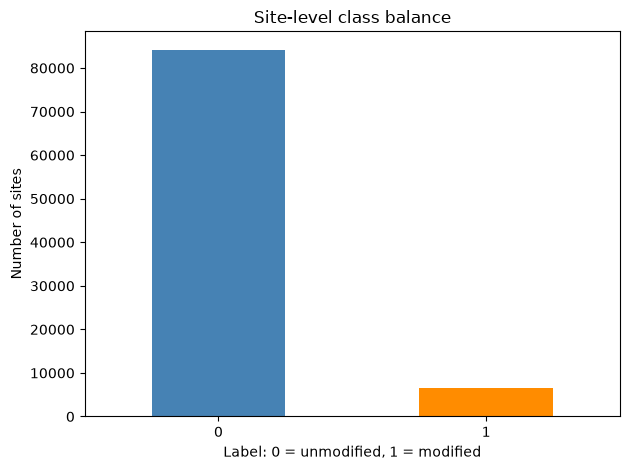

In [5]:
class_counts = (
    labelled_sites["label"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .sort_index()
)

class_summary = pd.DataFrame({
    "sites": class_counts,
    "percentage": class_counts / class_counts.sum() * 100,
})

display(class_summary)

class_counts.plot.bar(
    color=["steelblue", "darkorange"],
    rot=0,
)

plt.xlabel("Label: 0 = unmodified, 1 = modified")
plt.ylabel("Number of sites")
plt.title("Site-level class balance")
plt.tight_layout()
plt.show()

## Read coverage
Sites with few reads may have less stable summary statistics.

count    90810.000000
mean        87.082392
std        146.063085
min         20.000000
1%          20.000000
5%          21.000000
25%         27.000000
50%         40.000000
75%         77.000000
95%        312.000000
99%        893.000000
max        994.000000
Name: n_reads, dtype: float64

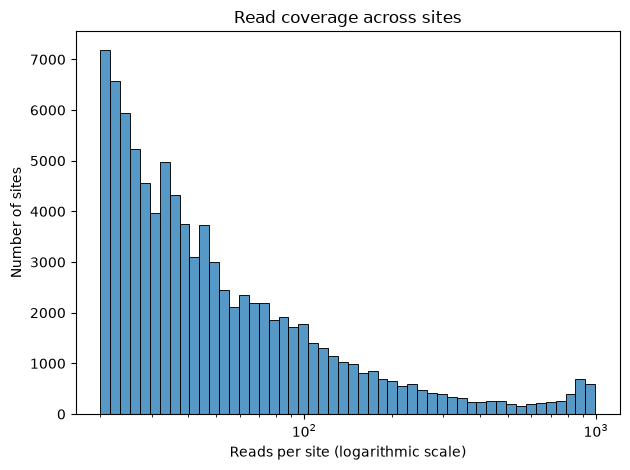

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0.0,84217.0,85.550233,144.146207,20.0,27.0,39.0,75.0,993.0
1.0,6593.0,106.653724,167.426167,20.0,29.0,47.0,96.0,994.0


In [6]:
display(
    sites["n_reads"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
)

sns.histplot(
    data=sites,
    x="n_reads",
    bins=50,
    log_scale=True,
)

plt.xlabel("Reads per site (logarithmic scale)")
plt.ylabel("Number of sites")
plt.title("Read coverage across sites")
plt.tight_layout()
plt.show()

display(
    labelled_sites.groupby("label")["n_reads"].describe()
)

In [7]:
# Descriptive cutoffs for EDA, not filtering rules.
coverage_summary = pd.DataFrame([
    {
        "condition": f"n_reads < {cutoff}",
        "sites": int((sites["n_reads"] < cutoff).sum()),
        "percentage": 100 * (sites["n_reads"] < cutoff).mean(),
    }
    for cutoff in [5, 10, 20]
])

display(coverage_summary)

,condition,sites,percentage
0,n_reads < 5,0,0.0
1,n_reads < 10,0,0.0
2,n_reads < 20,0,0.0


## Sites per gene
These are transcript-position sites. Different transcripts from the same gene may refer to overlapping biological positions; this does not count unique genomic loci.

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: n_sites, dtype: float64

,n_sites
gene_id,


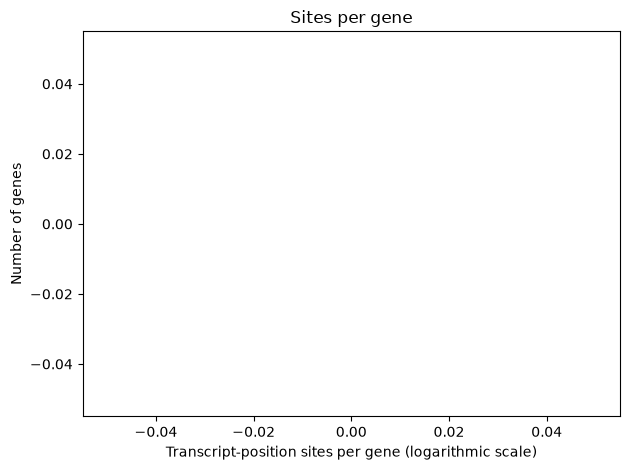

In [8]:
sites_per_gene = (
    sites.dropna(subset=["gene_id"])
    .groupby("gene_id")
    .size()
    .rename("n_sites")
    .sort_values(ascending=False)
)

display(sites_per_gene.describe())
display(sites_per_gene.head(5).to_frame())

sns.histplot(
    x=sites_per_gene,
    bins=50,
    log_scale=True,
)

plt.xlabel("Transcript-position sites per gene (logarithmic scale)")
plt.ylabel("Number of genes")
plt.title("Sites per gene")
plt.tight_layout()
plt.show()

## Full 7-mer freq by label
The plotted percentages use all sites in each class as the denominator, not just the top 20 sequences.

label,0,1
sequence,,
AAAACAA,766,22
AGAACAA,632,19
AAGACCA,634,10
CTGACCA,630,14
AGGACCT,574,57
GAAACTG,587,43
CTGACCC,619,8
TGGACCT,560,67
TGGACAA,566,57


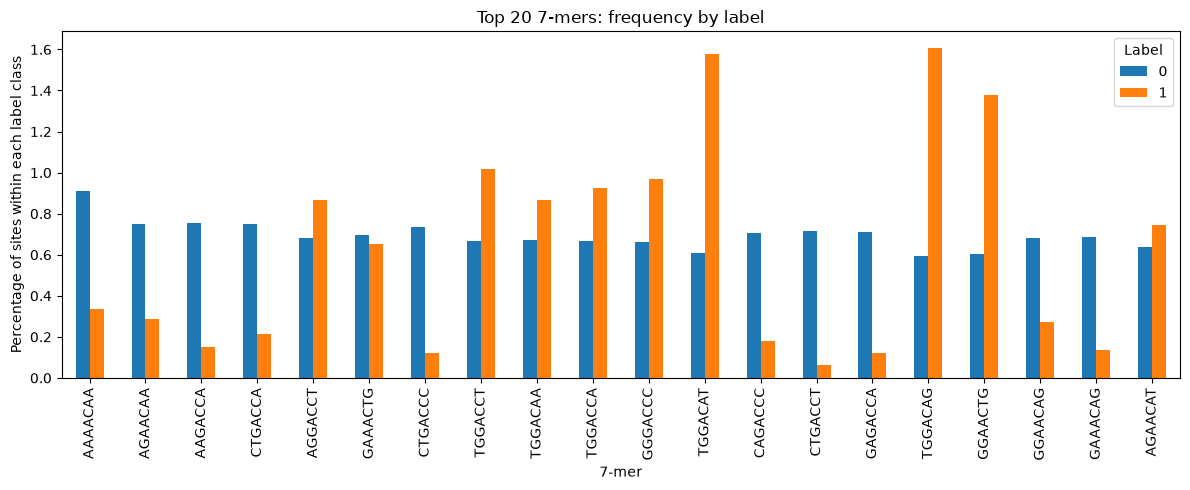

In [9]:
sequence_counts = pd.crosstab(
    labelled_sites["sequence"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

# Each column sums to 100% when that label class is present.
sequence_percentages = (
    sequence_counts
    .div(
        sequence_counts.sum(axis=0).replace(0, float("nan")),
        axis="columns",
    )
    * 100
)

top_sequences = (
    sequence_counts.sum(axis=1)
    .nlargest(20)
    .index
)

display(sequence_counts.loc[top_sequences])

sequence_percentages.loc[top_sequences].plot.bar(
    figsize=(12, 5),
)

plt.xlabel("7-mer")
plt.ylabel("Percentage of sites within each label class")
plt.title("Top 20 7-mers: frequency by label")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

## 5-mer freq by label

label,0,1
central_5mer,,
GGACC,5998,564
GGACA,5576,938
TGACC,6170,100
AAACA,6099,117
TGACA,5674,212
AGACC,5633,145
GAACA,5327,372
AGACA,5188,271
GGACT,4229,1186


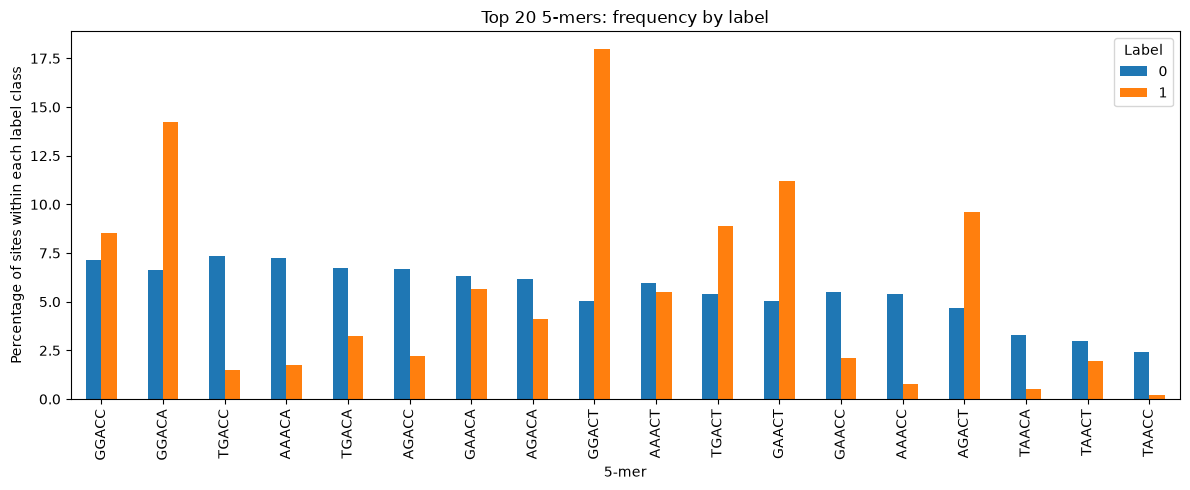

In [10]:
sequence_counts = pd.crosstab(
    labelled_sites["central_5mer"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

# Each column sums to 100% when that label class is present.
sequence_percentages = (
    sequence_counts
    .div(
        sequence_counts.sum(axis=0).replace(0, float("nan")),
        axis="columns",
    )
    * 100
)

top_sequences = (
    sequence_counts.sum(axis=1)
    .nlargest(20)
    .index
)

display(sequence_counts.loc[top_sequences])

sequence_percentages.loc[top_sequences].plot.bar(
    figsize=(12, 5),
)

plt.xlabel("5-mer")
plt.ylabel("Percentage of sites within each label class")
plt.title("Top 20 5-mers: frequency by label")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

## Sequence motifs
Interpret positive fractions alongside site counts: a motif represented by very few sites has a less reliable estimate.

label,unmodified_sites,modified_sites,total_sites,positive_fraction
central_5mer,,,,
GGACC,5998,564,6562,0.085949
GGACA,5576,938,6514,0.143998
TGACC,6170,100,6270,0.015949
AAACA,6099,117,6216,0.018822
TGACA,5674,212,5886,0.036018
AGACC,5633,145,5778,0.025095
GAACA,5327,372,5699,0.065275
AGACA,5188,271,5459,0.049643
GGACT,4229,1186,5415,0.219021


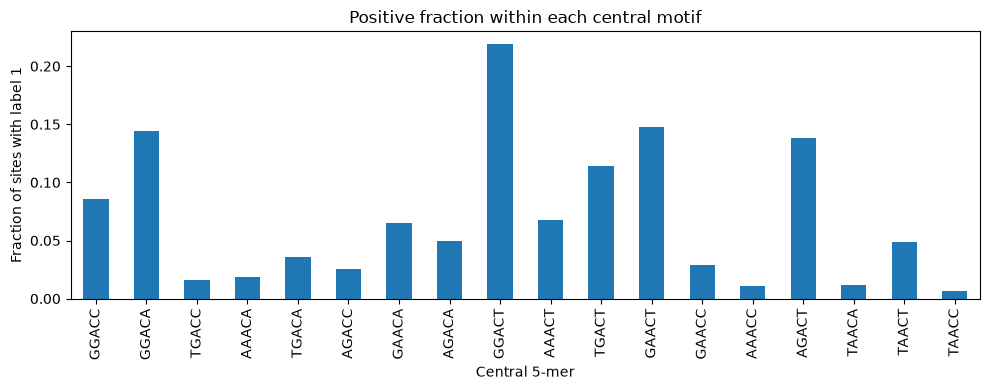

In [11]:
motif_counts = pd.crosstab(
    labelled_sites["central_5mer"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

motif_summary = motif_counts.rename(
    columns={0: "unmodified_sites", 1: "modified_sites"}
)

motif_summary["total_sites"] = motif_summary.sum(axis=1)

motif_summary["positive_fraction"] = (
    motif_summary["modified_sites"]
    / motif_summary["total_sites"]
)

motif_summary = motif_summary.sort_values(
    "total_sites", ascending=False
)

display(motif_summary)

motif_summary["positive_fraction"].plot.bar(
    figsize=(10, 4)
)

plt.xlabel("Central 5-mer")
plt.ylabel("Fraction of sites with label 1")
plt.title("Positive fraction within each central motif")
plt.tight_layout()
plt.show()

In [12]:
# Data-quality check to investigate unexpected motifs before deciding whether to exclude anything  
valid_motif = sites["central_5mer"].str.fullmatch(
    r"[AGT][AG]AC[ACT]",
    na=False,
)

print("Sites outside the expected DRACH motif:", (~valid_motif).sum())

display(
    sites.loc[
        ~valid_motif,
        SITE_KEYS + ["sequence", "central_5mer"]
    ].head()
)

Sites outside the expected DRACH motif: 0


,transcript_id,transcript_position,sequence,central_5mer


## Central signal features

In [13]:
central_features = [
    "central_dwell",
    "central_signal_sd",
    "central_signal_mean",
]

print("Label dtype:", labelled_reads["label"].dtype)

display(
    labelled_reads["label"]
    .value_counts(dropna=False)
)

print(
    "Label examples:",
    [repr(value) for value in labelled_reads["label"].dropna().unique()[:10]]
)

display(
    labelled_reads[central_features].dtypes
)

Label dtype: float64


label
0.0    7204784
1.0     703168
Name: count, dtype: int64

Label examples: ['np.float64(0.0)', 'np.float64(1.0)']


central_dwell          float64
central_signal_sd      float64
central_signal_mean    float64
dtype: object

central_dwell: excluded 0 rows with missing labels or non-finite feature values.
central_signal_sd: excluded 0 rows with missing labels or non-finite feature values.
central_signal_mean: excluded 0 rows with missing labels or non-finite feature values.


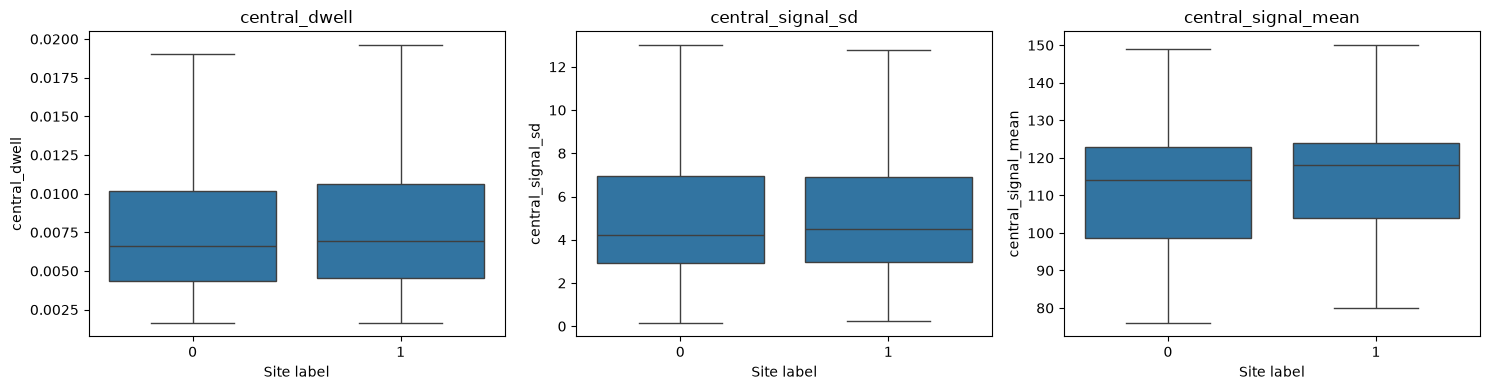

In [14]:
labels = pd.to_numeric(labelled_reads["label"], errors="raise")

unexpected = labels.notna() & ~labels.isin([0, 1])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, central_features):
    values = pd.to_numeric(
        labelled_reads[feature],
        errors="raise",
    )

    valid = labels.notna() & values.notna() & np.isfinite(values)

    plot_data = pd.DataFrame({
        "Site label": labels.loc[valid].astype(int).astype(str),
        "Value": values.loc[valid],
    })

    order = [
        label for label in ["0", "1"]
        if plot_data["Site label"].eq(label).any()
    ]

    print(
        f"{feature}: excluded {(~valid).sum():,} rows "
        "with missing labels or non-finite feature values."
    )

    if not order:
        ax.set_title(f"{feature}: no valid observations")
        ax.axis("off")
        continue

    sns.boxplot(
        data=plot_data,
        x="Site label",
        y="Value",
        order=order,
        showfliers=False,
        ax=ax,
    )

    ax.set_title(feature)
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## Compare site averages

label
0.0    84217
1.0     6593
Name: sites, dtype: int64

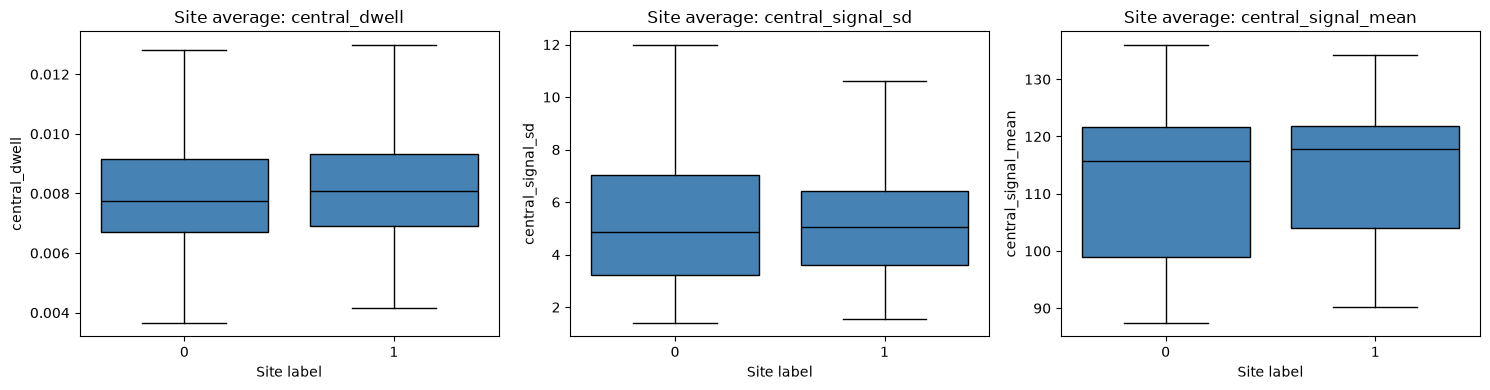

In [15]:
central_site_means = (
    labelled_reads
    .groupby(SITE_KEYS, as_index=False)[central_features]
    .mean()
    .merge(
        labelled_sites[SITE_KEYS + ["label"]],
        on=SITE_KEYS,
        how="left",
        validate="one_to_one",
    )
)

# Convert strings such as "0" and "1" to numeric values.
central_site_means["label"] = pd.to_numeric(
    central_site_means["label"],
    errors="raise",
)

labels = central_site_means["label"]

display(central_site_means.groupby("label").size().rename("sites"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, central_features):
    groups = []
    group_names = []

    for label in [0, 1]:
        values = pd.to_numeric(
            central_site_means.loc[
                central_site_means["label"].eq(label),
                feature,
            ],
            errors="raise",
        ).to_numpy(dtype=float, na_value=np.nan)

        finite = np.isfinite(values)

        values = values[finite]

        if values.size:
            groups.append(values)
            group_names.append(str(label))

    positions = np.arange(1, len(groups) + 1)

    box = ax.boxplot(
        groups,
        positions=positions,
        widths=0.8,
        showfliers=False,
        patch_artist=True,
        medianprops={"color": "black"},
    )

    for patch in box["boxes"]:
        patch.set_facecolor("steelblue")
        
    ax.set_xticks(positions)
    ax.set_xticklabels(group_names)

    ax.set_title(f"Site average: {feature}")
    ax.set_xlabel("Site label")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()